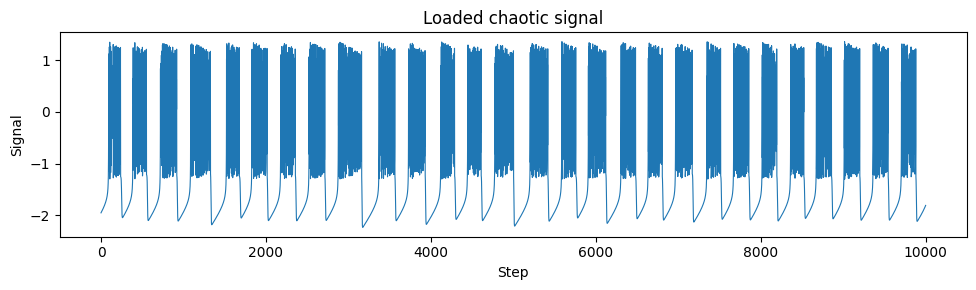

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import itertools
import time
from numba import njit
from sklearn.linear_model import Ridge, Lasso

np.random.seed(42)

# ==========================================================
# USER SETTINGS
# ==========================================================
DATA_PATH = "../../../data/chaotic_data/rulkov_map.csv"
COLUMN_IDX = 0

train_len        = 4000
test_start       = 4000
test_len         = 1000
seed             = 42

regression_model = "ridge"   # "ridge" or "lasso"
READOUT_FEATURES = "quadratic"  # "linear" or "quadratic"
TRAIN_NOISE_STD  = 1e-4

# random-search budget
N_TRIALS = 250

# if True, reject reservoirs with very poor separation after STDP
USE_SEPARATION_CHECK = True

# ==========================================================
# SIMPLE SCALERS (self-contained)
# ==========================================================
def fit_scaler(x, method="minmax11"):
    x = np.asarray(x).reshape(-1, 1)
    if method == "minmax11":
        xmin = x.min(axis=0)
        xmax = x.max(axis=0)
        scale = xmax - xmin
        scale[scale == 0] = 1.0
        return {"method": method, "xmin": xmin, "xmax": xmax, "scale": scale}
    elif method == "zscore":
        mean = x.mean(axis=0)
        std = x.std(axis=0)
        std[std == 0] = 1.0
        return {"method": method, "mean": mean, "std": std}
    else:
        raise ValueError(f"Unknown scaling method: {method}")

def transform_array(x, scaler):
    x = np.asarray(x).reshape(-1, 1)
    if scaler["method"] == "minmax11":
        return 2.0 * (x - scaler["xmin"]) / scaler["scale"] - 1.0
    elif scaler["method"] == "zscore":
        return (x - scaler["mean"]) / scaler["std"]
    else:
        raise ValueError("Unknown scaler method.")

def inverse_transform_array(x, scaler):
    x = np.asarray(x).reshape(-1, 1)
    if scaler["method"] == "minmax11":
        return 0.5 * (x + 1.0) * scaler["scale"] + scaler["xmin"]
    elif scaler["method"] == "zscore":
        return x * scaler["std"] + scaler["mean"]
    else:
        raise ValueError("Unknown scaler method.")

# ==========================================================
# LOAD DATA
# ==========================================================
dataset = np.loadtxt(DATA_PATH, delimiter=",")
if dataset.ndim == 2:
    dataset = dataset[:, COLUMN_IDX]
dataset = dataset.astype(np.float64)

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(dataset, lw=0.8)
ax.set_title("Loaded chaotic signal")
ax.set_xlabel("Step")
ax.set_ylabel("Signal")
plt.tight_layout()
plt.show()

data  = dataset.reshape(-1, 1)
X_raw = data[:-1]
Y_raw = data[1:]

X_train_raw = X_raw[:train_len]
Y_train_raw = Y_raw[:train_len]
X_test_raw  = X_raw[test_start:test_start + test_len]
Y_test_raw  = Y_raw[test_start:test_start + test_len]

# ==========================================================
# NUMBA KERNELS
# ==========================================================
@njit(cache=True)
def _encode_population(x_scalar, mu, sigma_enc):
    N = mu.shape[0]
    out = np.empty(N)
    inv_2s2 = 1.0 / (2.0 * sigma_enc * sigma_enc)
    for i in range(N):
        d = x_scalar - mu[i]
        out[i] = np.exp(-d * d * inv_2s2)
    return out

@njit(cache=True)
def _compute_input_current(inp_act, W_in):
    N = W_in.shape[0]
    M = W_in.shape[1]
    out = np.zeros(N)
    for i in range(N):
        s = 0.0
        for j in range(M):
            s += W_in[i, j] * inp_act[j]
        out[i] = s
    return out

@njit(cache=True)
def _simulate_window(
    V, I_syn, refrac, trace_pre, trace_post,
    W_rec, I_input,
    n_substeps,
    V_rest, V_reset, V_thresh,
    decay_mem, drive_scale, decay_syn,
    refrac_steps,
    stdp_enabled,
    decay_trace,
    A_plus, A_minus, w_min, w_max,
):
    """
    Advance the reservoir for one sample window.
    Returns spike counts during that window.
    STDP update:
      on presyn spike of neuron j:   W[post, j] += A_plus  * trace_post[post]
      on post syn spike of neuron i: W[i,  pre] -= A_minus * trace_pre[pre]
    """
    N = V.shape[0]
    spike_counts = np.zeros(N)

    for _ in range(n_substeps):
        # decay traces and syn currents
        for i in range(N):
            trace_pre[i]  *= decay_trace
            trace_post[i] *= decay_trace
            I_syn[i]      *= decay_syn

        # membrane update
        for i in range(N):
            if refrac[i] <= 0:
                V[i] = V_rest + (V[i] - V_rest) * decay_mem + (I_syn[i] + I_input[i]) * drive_scale
            else:
                refrac[i] -= 1

        # gather spikes
        spiked = np.zeros(N, dtype=np.uint8)
        for i in range(N):
            if V[i] >= V_thresh:
                spiked[i] = 1
                spike_counts[i] += 1.0
                V[i] = V_reset
                refrac[i] = refrac_steps

        # synaptic delivery + STDP
        # W_rec[post, pre]
        for pre in range(N):
            if spiked[pre] == 1:
                trace_pre[pre] += 1.0

                # pre spike causes synaptic delivery
                for post in range(N):
                    I_syn[post] += W_rec[post, pre]

                # causal potentiation: pre now, post trace from recent post spikes
                if stdp_enabled:
                    for post in range(N):
                        delta = A_plus * trace_post[post]
                        new_w = W_rec[post, pre] + delta
                        if new_w > w_max:
                            new_w = w_max
                        elif new_w < w_min:
                            new_w = w_min
                        W_rec[post, pre] = new_w

        for post in range(N):
            if spiked[post] == 1:
                trace_post[post] += 1.0

                # anti-causal depression: post now, recent pre traces
                if stdp_enabled:
                    for pre in range(N):
                        delta = A_minus * trace_pre[pre]
                        new_w = W_rec[post, pre] - delta
                        if new_w > w_max:
                            new_w = w_max
                        elif new_w < w_min:
                            new_w = w_min
                        W_rec[post, pre] = new_w

    return spike_counts

@njit(cache=True)
def _run_sequence(
    input_sequence,
    V, I_syn, refrac, filt, trace_pre, trace_post,
    W_rec, W_in, mu, sigma_enc,
    n_substeps,
    V_rest, V_reset, V_thresh,
    decay_mem, drive_scale, decay_syn, decay_filt,
    refrac_steps,
    stdp_enabled,
    decay_trace,
    A_plus, A_minus, w_min, w_max,
):
    T = input_sequence.shape[0]
    N = V.shape[0]
    states = np.zeros((T, N))

    for t in range(T):
        x = input_sequence[t, 0]
        inp_act = _encode_population(x, mu, sigma_enc)
        I_input = _compute_input_current(inp_act, W_in)

        counts = _simulate_window(
            V, I_syn, refrac, trace_pre, trace_post,
            W_rec, I_input,
            n_substeps,
            V_rest, V_reset, V_thresh,
            decay_mem, drive_scale, decay_syn,
            refrac_steps,
            stdp_enabled,
            decay_trace,
            A_plus, A_minus, w_min, w_max,
        )

        for i in range(N):
            filt[i] = filt[i] * decay_filt + counts[i]
            states[t, i] = filt[i]

    return states

@njit(cache=True)
def _run_one_step(
    x_scalar,
    V, I_syn, refrac, filt, trace_pre, trace_post,
    W_rec, W_in, mu, sigma_enc,
    n_substeps,
    V_rest, V_reset, V_thresh,
    decay_mem, drive_scale, decay_syn, decay_filt,
    refrac_steps,
):
    x_arr = np.empty((1, 1))
    x_arr[0, 0] = x_scalar
    states = _run_sequence(
        x_arr,
        V, I_syn, refrac, filt, trace_pre, trace_post,
        W_rec, W_in, mu, sigma_enc,
        n_substeps,
        V_rest, V_reset, V_thresh,
        decay_mem, drive_scale, decay_syn, decay_filt,
        refrac_steps,
        False,    # no STDP during inference
        1.0, 0.0, 0.0, -1e9, 1e9
    )
    return states[0].copy()

# ==========================================================
# LSM WRAPPER
# ==========================================================
class SpikingLSM:
    """
    Paper-inspired LSM:
      - LIF reservoir
      - population coding
      - optional STDP pre-exposure
      - frozen reservoir during supervised readout training
    """

    def __init__(
        self,
        N_liquid=400,
        N_input=50,
        tau_mem=30.0,
        tau_syn=5.0,
        tau_filt=50.0,
        tau_trace=20.0,
        dt=1.0,
        step_duration=25.0,
        V_rest=-65.0,
        V_reset=-65.0,
        V_thresh=-50.0,
        refrac_steps=2,
        exc_frac=0.8,
        conn_prob=0.08,
        input_conn_prob=0.3,
        w_exc=0.04,
        w_inh_mag=0.12,
        w_input=1.0,
        spectral_radius=0.95,
        sigma_enc=0.2,
        rng_seed=42,
        A_plus=1e-4,
        A_minus=1.2e-4,
        w_min=-0.5,
        w_max=0.5,
    ):
        self.N = N_liquid
        self.N_input = N_input
        self.n_substeps = int(round(step_duration / dt))

        self.V_rest = V_rest
        self.V_reset = V_reset
        self.V_thresh = V_thresh
        self.refrac_steps = refrac_steps

        self.decay_mem   = np.exp(-dt / tau_mem)
        self.drive_scale = 1.0 - self.decay_mem
        self.decay_syn   = np.exp(-dt / tau_syn)
        self.decay_filt  = np.exp(-step_duration / tau_filt)
        self.decay_trace = np.exp(-dt / tau_trace)

        self.mu = np.linspace(-1.0, 1.0, N_input)
        self.sigma_enc = sigma_enc

        self.A_plus = A_plus
        self.A_minus = A_minus
        self.w_min = w_min
        self.w_max = w_max

        rng = np.random.RandomState(rng_seed)

        # recurrent weights: W[post, pre]
        W_rec = np.zeros((N_liquid, N_liquid), dtype=np.float64)
        mask = rng.rand(N_liquid, N_liquid) < conn_prob
        np.fill_diagonal(mask, False)

        n_exc = int(exc_frac * N_liquid)
        neuron_sign = np.ones(N_liquid)
        neuron_sign[n_exc:] = -1.0

        for pre in range(N_liquid):
            if neuron_sign[pre] > 0:
                W_rec[:, pre][mask[:, pre]] = rng.uniform(0.0, w_exc, size=np.sum(mask[:, pre]))
            else:
                W_rec[:, pre][mask[:, pre]] = -rng.uniform(0.0, w_inh_mag, size=np.sum(mask[:, pre]))

        # spectral-radius style scaling
        try:
            eigvals = np.linalg.eigvals(W_rec)
            sr = np.max(np.abs(eigvals))
            if sr > 1e-12:
                W_rec *= (spectral_radius / sr)
        except np.linalg.LinAlgError:
            pass

        self.W_rec = W_rec

        W_in = np.zeros((N_liquid, N_input), dtype=np.float64)
        in_mask = rng.rand(N_liquid, N_input) < input_conn_prob
        W_in[in_mask] = rng.uniform(0.0, w_input, size=np.sum(in_mask))
        self.W_in = W_in

        self.reset_state()

    def reset_state(self):
        self.V = np.full(self.N, self.V_rest, dtype=np.float64)
        self.I_syn = np.zeros(self.N, dtype=np.float64)
        self.refrac = np.zeros(self.N, dtype=np.int32)
        self.filt = np.zeros(self.N, dtype=np.float64)
        self.trace_pre = np.zeros(self.N, dtype=np.float64)
        self.trace_post = np.zeros(self.N, dtype=np.float64)

    def copy_recurrent_weights(self):
        return self.W_rec.copy()

    def restore_recurrent_weights(self, W):
        self.W_rec = W.copy()

    def run_sequence(self, input_sequence, stdp_enabled=False):
        return _run_sequence(
            np.ascontiguousarray(input_sequence),
            self.V, self.I_syn, self.refrac, self.filt, self.trace_pre, self.trace_post,
            self.W_rec, self.W_in, self.mu, self.sigma_enc,
            self.n_substeps,
            self.V_rest, self.V_reset, self.V_thresh,
            self.decay_mem, self.drive_scale, self.decay_syn, self.decay_filt,
            self.refrac_steps,
            stdp_enabled,
            self.decay_trace,
            self.A_plus, self.A_minus, self.w_min, self.w_max
        )

    def run_one_step(self, x_scalar):
        return _run_one_step(
            float(x_scalar),
            self.V, self.I_syn, self.refrac, self.filt, self.trace_pre, self.trace_post,
            self.W_rec, self.W_in, self.mu, self.sigma_enc,
            self.n_substeps,
            self.V_rest, self.V_reset, self.V_thresh,
            self.decay_mem, self.drive_scale, self.decay_syn, self.decay_filt,
            self.refrac_steps,
        )

# ==========================================================
# READOUT FEATURES
# ==========================================================
def make_features(S, mode="quadratic"):
    if mode == "linear":
        return S
    elif mode == "quadratic":
        return np.hstack([S, S**2])
    else:
        raise ValueError(f"Unknown feature mode: {mode}")

# ==========================================================
# SEPARATION PROXY
# Inspired by the paper's separation property idea:
# different nearby inputs should create separable liquid states.
# ==========================================================
def separation_proxy(lsm, seq_a, seq_b):
    lsm.reset_state()
    Sa = lsm.run_sequence(seq_a, stdp_enabled=False)
    lsm.reset_state()
    Sb = lsm.run_sequence(seq_b, stdp_enabled=False)

    if Sa.shape[0] != Sb.shape[0]:
        T = min(Sa.shape[0], Sb.shape[0])
        Sa = Sa[:T]
        Sb = Sb[:T]

    d = np.mean(np.linalg.norm(Sa - Sb, axis=1))
    return float(d)

def build_perturbed_pair(x_seq, noise_std=0.01, seed=0):
    rng = np.random.RandomState(seed)
    a = x_seq.copy()
    b = x_seq.copy() + rng.normal(0.0, noise_std, size=x_seq.shape)
    return a, b

# ==========================================================
# EVALUATION
# ==========================================================
def evaluate_lsm(params, rng_seed=42):
    try:
        normalization   = params["normalization"]
        train_warmup    = params["train_warmup"]
        test_warmup     = params["test_warmup"]
        N_liquid        = params["N_liquid"]
        step_duration   = params["step_duration"]
        tau_mem         = params["tau_mem"]
        tau_syn         = params["tau_syn"]
        tau_filt        = params["tau_filt"]
        tau_trace       = params["tau_trace"]
        conn_prob       = params["conn_prob"]
        input_conn_prob = params["input_conn_prob"]
        spectral_radius = params["spectral_radius"]
        w_exc           = params["w_exc"]
        inh_ratio       = params["inh_ratio"]
        w_input         = params["w_input"]
        sigma_enc       = params["sigma_enc"]
        stdp_exposure   = params["stdp_exposure"]
        A_plus          = params["A_plus"]
        A_minus         = params["A_minus"]
        regression      = params["regression"]

        if test_warmup >= test_len:
            return np.inf, None

        scaler  = fit_scaler(X_train_raw, method=normalization)
        X_train = transform_array(X_train_raw, scaler)
        Y_train = transform_array(Y_train_raw, scaler)
        X_test  = transform_array(X_test_raw, scaler)
        Y_test  = transform_array(Y_test_raw, scaler)

        x_lo = float(X_train.min()) - 0.05
        x_hi = float(X_train.max()) + 0.05

        lsm = SpikingLSM(
            N_liquid=N_liquid,
            N_input=50,
            tau_mem=tau_mem,
            tau_syn=tau_syn,
            tau_filt=tau_filt,
            tau_trace=tau_trace,
            dt=1.0,
            step_duration=step_duration,
            conn_prob=conn_prob,
            input_conn_prob=input_conn_prob,
            w_exc=w_exc,
            w_inh_mag=inh_ratio * w_exc,
            w_input=w_input,
            spectral_radius=spectral_radius,
            sigma_enc=sigma_enc,
            rng_seed=rng_seed,
            A_plus=A_plus,
            A_minus=A_minus,
            w_min=-0.5,
            w_max=0.5,
        )

        # -------------------------------
        # 1) Optional unsupervised STDP exposure
        # -------------------------------
        W_before = lsm.copy_recurrent_weights()

        if stdp_exposure > 0:
            lsm.reset_state()
            expose_seq = X_train[:stdp_exposure]
            _ = lsm.run_sequence(expose_seq, stdp_enabled=True)

        # -------------------------------
        # 2) Separation check
        # -------------------------------
        sep_score = None
        if USE_SEPARATION_CHECK:
            probe = X_train[:300]
            a, b = build_perturbed_pair(probe, noise_std=0.01, seed=rng_seed)
            sep_score = separation_proxy(lsm, a, b)

            # reject collapsed or dead reservoirs
            if (not np.isfinite(sep_score)) or (sep_score < 1e-4):
                return np.inf, None

        # -------------------------------
        # 3) Freeze reservoir, collect training states
        # -------------------------------
        lsm.reset_state()
        S_train = lsm.run_sequence(X_train, stdp_enabled=False)

        mean_activity = S_train.mean()
        if (not np.isfinite(mean_activity)) or mean_activity < 1e-6 or mean_activity > 1e6:
            return np.inf, None

        S_fit = S_train[train_warmup:]
        Y_fit = Y_train[train_warmup:, 0]

        if TRAIN_NOISE_STD > 0:
            rng_noise = np.random.RandomState(rng_seed + 123)
            S_fit = S_fit + rng_noise.normal(0.0, TRAIN_NOISE_STD, size=S_fit.shape)

        F_fit = make_features(S_fit, READOUT_FEATURES)

        if regression_model == "ridge":
            readout = Ridge(alpha=regression)
        else:
            readout = Lasso(alpha=regression, max_iter=10000)

        readout.fit(F_fit, Y_fit)

        # -------------------------------
        # 4) Test sync
        # -------------------------------
        lsm.reset_state()
        _ = lsm.run_sequence(X_test[:test_warmup], stdp_enabled=False)

        # -------------------------------
        # 5) Closed-loop rollout
        # -------------------------------
        pred_len = test_len - test_warmup
        Y_true_scaled = Y_test[test_warmup:test_warmup + pred_len, 0]
        Y_pred_scaled = np.zeros(pred_len)

        current_input = float(X_test[test_warmup, 0])

        for k in range(pred_len):
            state = lsm.run_one_step(current_input)
            feat = make_features(state.reshape(1, -1), READOUT_FEATURES)
            pred = readout.predict(feat)[0]

            if not np.isfinite(pred) or abs(pred) > 1e6:
                return np.inf, None

            pred = float(np.clip(pred, x_lo, x_hi))
            Y_pred_scaled[k] = pred
            current_input = pred

        rmse = np.sqrt(np.mean((Y_true_scaled - Y_pred_scaled) ** 2))
        denom = np.std(Y_true_scaled)
        if denom == 0:
            return np.inf, None

        nrmse = rmse / denom

        aux = {
            "scaler": scaler,
            "sep_score": sep_score,
            "W_before": W_before,
            "W_after": lsm.copy_recurrent_weights(),
        }
        return float(nrmse), aux

    except Exception as e:
        print("ERROR:", e)
        return np.inf, None

# ==========================================================
# PARAMETER SEARCH SPACE
# ==========================================================
param_grid = {
    "normalization":   ["minmax11"],  # bounded maps like Rulkov/logistic
    "train_warmup":    [150, 250],
    "test_warmup":     [200, 300],

    "N_liquid":        [300, 500, 800],
    "step_duration":   [15.0, 25.0, 35.0],
    "tau_mem":         [20.0, 40.0, 80.0],
    "tau_syn":         [3.0, 5.0, 8.0],
    "tau_filt":        [20.0, 50.0, 100.0, 200.0],
    "tau_trace":       [10.0, 20.0, 40.0],

    "conn_prob":       [0.05, 0.08],
    "input_conn_prob": [0.2, 0.4],
    "spectral_radius": [0.80, 0.95, 1.05, 1.20],

    "w_exc":           [0.03, 0.05],
    "inh_ratio":       [2.0, 3.0, 5.0],
    "w_input":         [0.5, 1.0, 2.0],
    "sigma_enc":       [0.12, 0.20, 0.30],

    # STDP exposure length in number of training samples
    "stdp_exposure":   [0, 200, 500, 1000],

    # small STDP amplitudes; too large often destabilizes
    "A_plus":          [5e-5, 1e-4],
    "A_minus":         [6e-5, 1.2e-4],

    "regression":      [1e-8, 1e-6, 1e-4, 1e-2],
}

keys = list(param_grid.keys())
all_combos = list(itertools.product(*[param_grid[k] for k in keys]))

rng_sampler = np.random.RandomState(seed)
n_trials = min(N_TRIALS, len(all_combos))
idx = rng_sampler.choice(len(all_combos), size=n_trials, replace=False)
combos = [all_combos[i] for i in idx]

print(f"Full grid size      : {len(all_combos)}")
print(f"Random-sampled size : {len(combos)}")

# ==========================================================
# WARM-UP COMPILE
# ==========================================================
print("Compiling Numba kernels...")
t0 = time.time()
_dummy = SpikingLSM(N_liquid=50, rng_seed=0)
_dummy_in = np.zeros((10, 1))
_dummy.run_sequence(_dummy_in, stdp_enabled=False)
_dummy.run_sequence(_dummy_in, stdp_enabled=True)
_dummy.run_one_step(0.0)
print(f"Compilation done in {time.time() - t0:.2f}s")

# ==========================================================
# RUN SEARCH
# ==========================================================
results = []
best_nrmse = np.inf
best_params = None
best_aux = None

t_search = time.time()

for i, combo in enumerate(combos):
    params = dict(zip(keys, combo))
    nrmse, aux = evaluate_lsm(params, rng_seed=seed)
    row = params.copy()
    row["nrmse"] = nrmse
    if aux is not None and aux["sep_score"] is not None:
        row["sep_score"] = aux["sep_score"]
    else:
        row["sep_score"] = np.nan
    results.append(row)

    if nrmse < best_nrmse:
        best_nrmse = nrmse
        best_params = params.copy()
        best_aux = aux

    if (i + 1) % 10 == 0 or (i + 1) == len(combos):
        elapsed = time.time() - t_search
        eta = elapsed / (i + 1) * (len(combos) - (i + 1))
        print(f"[{i+1}/{len(combos)}] elapsed={elapsed:.1f}s ETA={eta:.1f}s best_NRMSE={best_nrmse:.6f}")

total_time = time.time() - t_search

# ==========================================================
# REPORT
# ==========================================================
print("\n" + "=" * 80)
print("LSM RANDOM SEARCH COMPLETE")
print(f"Train interval : [0:{train_len}]")
print(f"Test interval  : [{test_start}:{test_start + test_len}]")
print(f"Total time     : {total_time:.1f}s")
print(f"Best NRMSE     : {best_nrmse:.8f}")
print("Best parameters:")
for k, v in best_params.items():
    print(f"  {k:18s} = {v}")
print("=" * 80)

results_sorted = sorted(results, key=lambda r: r["nrmse"])

print("\nTop 10 configurations:")
header = (
    f"{'Rank':>4}  {'N':>4}  {'step':>5}  {'tau_m':>6}  {'tau_s':>6}  {'tau_f':>6}  "
    f"{'SR':>5}  {'w_in':>5}  {'stdp':>5}  {'A+':>8}  {'reg':>8}  {'NRMSE':>10}"
)
print(header)
print("-" * len(header))

for rank, r in enumerate(results_sorted[:10], 1):
    print(
        f"{rank:4d}  "
        f"{int(r['N_liquid']):4d}  "
        f"{r['step_duration']:5.1f}  "
        f"{r['tau_mem']:6.1f}  "
        f"{r['tau_syn']:6.1f}  "
        f"{r['tau_filt']:6.1f}  "
        f"{r['spectral_radius']:5.2f}  "
        f"{r['w_input']:5.2f}  "
        f"{int(r['stdp_exposure']):5d}  "
        f"{r['A_plus']:8.1e}  "
        f"{r['regression']:8.1e}  "
        f"{r['nrmse']:10.6f}"
    )

# ==========================================================
# REBUILD BEST MODEL
# ==========================================================
bp = best_params

best_scaler = fit_scaler(X_train_raw, method=bp["normalization"])
X_train_b = transform_array(X_train_raw, best_scaler)
Y_train_b = transform_array(Y_train_raw, best_scaler)
X_test_b  = transform_array(X_test_raw, best_scaler)
Y_test_b  = transform_array(Y_test_raw, best_scaler)

x_lo = float(X_train_b.min()) - 0.05
x_hi = float(X_train_b.max()) + 0.05

lsm = SpikingLSM(
    N_liquid=bp["N_liquid"],
    N_input=50,
    tau_mem=bp["tau_mem"],
    tau_syn=bp["tau_syn"],
    tau_filt=bp["tau_filt"],
    tau_trace=bp["tau_trace"],
    dt=1.0,
    step_duration=bp["step_duration"],
    conn_prob=bp["conn_prob"],
    input_conn_prob=bp["input_conn_prob"],
    w_exc=bp["w_exc"],
    w_inh_mag=bp["inh_ratio"] * bp["w_exc"],
    w_input=bp["w_input"],
    spectral_radius=bp["spectral_radius"],
    sigma_enc=bp["sigma_enc"],
    rng_seed=seed,
    A_plus=bp["A_plus"],
    A_minus=bp["A_minus"],
    w_min=-0.5,
    w_max=0.5,
)

# STDP exposure
if bp["stdp_exposure"] > 0:
    lsm.reset_state()
    _ = lsm.run_sequence(X_train_b[:bp["stdp_exposure"]], stdp_enabled=True)

# Train readout on frozen reservoir
lsm.reset_state()
S_train = lsm.run_sequence(X_train_b, stdp_enabled=False)

S_fit = S_train[bp["train_warmup"]:]
Y_fit = Y_train_b[bp["train_warmup"]:, 0]

if TRAIN_NOISE_STD > 0:
    rng_noise = np.random.RandomState(seed + 123)
    S_fit = S_fit + rng_noise.normal(0.0, TRAIN_NOISE_STD, size=S_fit.shape)

F_fit = make_features(S_fit, READOUT_FEATURES)

if regression_model == "ridge":
    readout = Ridge(alpha=bp["regression"])
else:
    readout = Lasso(alpha=bp["regression"], max_iter=10000)

readout.fit(F_fit, Y_fit)

# test synchronization
lsm.reset_state()
_ = lsm.run_sequence(X_test_b[:bp["test_warmup"]], stdp_enabled=False)

pred_len = test_len - bp["test_warmup"]
Y_pred_scaled = np.zeros(pred_len)
current_input = float(X_test_b[bp["test_warmup"], 0])

for k in range(pred_len):
    state = lsm.run_one_step(current_input)
    feat = make_features(state.reshape(1, -1), READOUT_FEATURES)
    pred = readout.predict(feat)[0]
    pred = float(np.clip(pred, x_lo, x_hi))
    Y_pred_scaled[k] = pred
    current_input = pred

Y_pred = inverse_transform_array(Y_pred_scaled.reshape(-1, 1), best_scaler).ravel()
Y_true = inverse_transform_array(
    Y_test_b[bp["test_warmup"]:bp["test_warmup"] + pred_len], best_scaler
).ravel()

mse = np.mean((Y_true - Y_pred)**2)
rmse = np.sqrt(mse)
nrmse = rmse / np.std(Y_true)

print("\nFinal best-model metrics (original scale):")
print(f"MSE   : {mse:.10f}")
print(f"RMSE  : {rmse:.10f}")
print(f"NRMSE : {nrmse:.10f}")
print(f"Mean state activity: {S_train.mean():.6f}")

# ==========================================================
# PLOT
# ==========================================================
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(np.arange(test_len), Y_test_raw[:, 0], c="green", lw=1.2, label="Ground truth")
ax.axvline(bp["test_warmup"], ls="--", c="k", lw=1.0, label="Warmup end")
ax.plot(
    np.arange(bp["test_warmup"], bp["test_warmup"] + pred_len),
    Y_pred,
    ls="--", c="red", lw=1.2, label="LSM closed-loop prediction"
)
ax.set_title(
    f"Best Spiking LSM | NRMSE={nrmse:.4f} | "
    f"N={bp['N_liquid']}, step={bp['step_duration']}, "
    f"tau_filt={bp['tau_filt']}, SR={bp['spectral_radius']}, "
    f"STDP={bp['stdp_exposure']}, reg={bp['regression']:.0e}"
)
ax.set_xlabel("Step")
ax.set_ylabel("Signal")
ax.legend()
plt.tight_layout()
plt.show()

# ==========================================================
# OPTIONAL: VISUALIZE STDP EFFECT ON WEIGHTS
# ==========================================================
if best_aux is not None:
    W_before = best_aux["W_before"]
    W_after  = best_aux["W_after"]

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    im0 = axes[0].imshow(W_before, aspect="auto")
    axes[0].set_title("W_rec before STDP")
    plt.colorbar(im0, ax=axes[0], fraction=0.046)

    im1 = axes[1].imshow(W_after, aspect="auto")
    axes[1].set_title("W_rec after STDP")
    plt.colorbar(im1, ax=axes[1], fraction=0.046)

    plt.tight_layout()
    plt.show()